# Student Performance Analysis

IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

LOAD DATASET

In [5]:
df = pd.read_csv("student_perfo_dataset.csv")
print(df.head())


  Name  Study_Hours  Sleep_Hours  Marks
0    A          2.0          7.0   40.0
1    B          3.0          NaN   45.0
2    C          4.0          6.0   50.0
3    D          NaN          5.0   55.0
4    E          6.0          5.0    NaN


HANDLE MISSING VALUES

In [6]:
print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())

Shape: (10, 4)

Missing values:
 Name           0
Study_Hours    1
Sleep_Hours    2
Marks          1
dtype: int64


DATA CLEANING

In [8]:
df["Study_Hours"].fillna(df["Study_Hours"].mean(), inplace=True)
df["Sleep_Hours"].fillna(df["Sleep_Hours"].mean(), inplace=True)
df["Marks"].fillna(df["Marks"].mean(), inplace=True)

C:\Users\Admin\AppData\Local\Temp\ipykernel_2428\2399072427.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Study_Hours"].fillna(df["Study_Hours"].mean(), inplace=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_2428\2399072427.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a 

DATA CLEANING

In [9]:
# Remove duplicates 
df.drop_duplicates(inplace=True)

# Reset index
df.reset_index(drop=True, inplace=True)

DATA BALANCING

In [10]:
df["Performance"] = df["Marks"] / df["Study_Hours"]

In [11]:
df["Category"] = pd.cut(df["Marks"],
                       bins=[0,50,75,100],
                       labels=["Low","Medium","High"])

In [12]:
print("\nAverage Marks:", df["Marks"].mean())
print("Category Count:\n", df["Category"].value_counts())


Average Marks: 60.55555555555556
Category Count:
 Category
Low       4
Medium    3
High      3
Name: count, dtype: int64


In [13]:
group_data = df.groupby("Category")["Marks"].mean()
print(group_data)

Category
Low       41.250000
Medium    61.851852
High      85.000000
Name: Marks, dtype: float64


C:\Users\Admin\AppData\Local\Temp\ipykernel_2428\3124740443.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_data = df.groupby("Category")["Marks"].mean()


Bar Plot

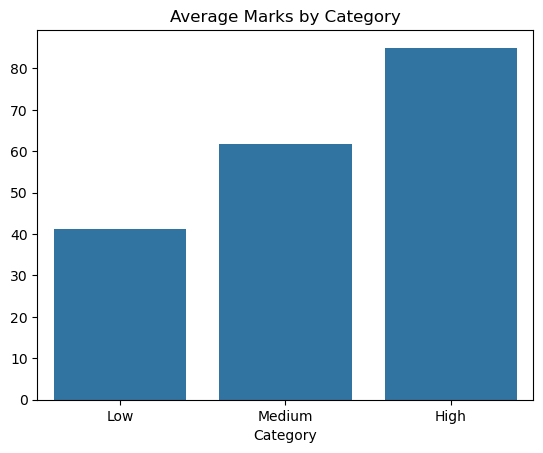

In [14]:
sns.barplot(x=group_data.index, y=group_data.values)
plt.title("Average Marks by Category")
plt.show()

Scatter Plot

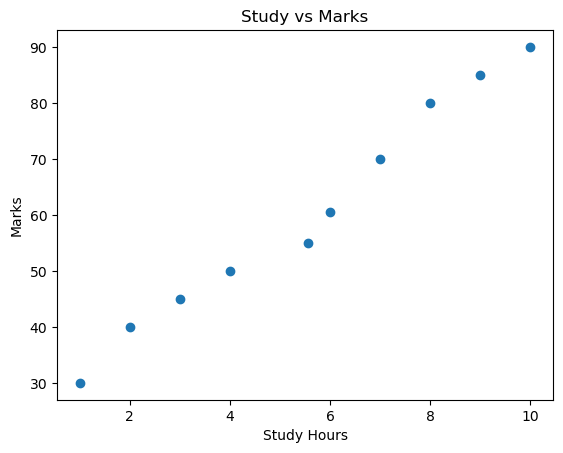

In [15]:
plt.scatter(df["Study_Hours"], df["Marks"])
plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.title("Study vs Marks")
plt.show()

Line Plot

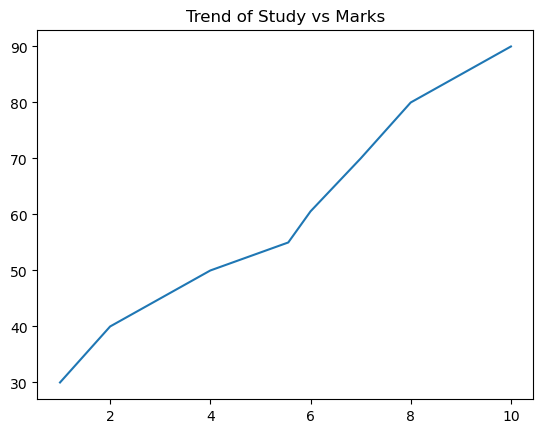

In [16]:
df_sorted = df.sort_values("Study_Hours")

plt.plot(df_sorted["Study_Hours"], df_sorted["Marks"])
plt.title("Trend of Study vs Marks")
plt.show()

In [17]:
df.to_csv("cleaned_students.csv", index=False)
print("Clean dataset saved!")

Clean dataset saved!
